# v7 — Latin-1 encoding features

**Base:** `features_v3.parquet` (22 features) + `content_param_density` (v6) + 2 candidatas en memoria = 25 features  
**MLflow experiment:** `mlsec-model-a`

## Hipótesis

La inspección del CSV crudo en v6 identificó el root cause de los 938 FP: `content_pct_density` no distingue encoding Latin-1 (vocales acentuadas españolas: `%F1`=ñ, `%ED`=í, `%FA`=ú) de encoding de ataque (`%27`=', `%3C`=<). Los FP son formularios legítimos de una tienda española con nombres y contraseñas en español.

Los ataques nunca usan encoding Latin-1 (`%C0`–`%FF`) porque:
1. El parser SQL/HTML no espera ñ — el payload se corrompería
2. Los payloads efectivos son mínimos y precisos — nada innecesario
3. Mezclar encodings puede corromper el string en el servidor

**Features candidatas:**
- `content_pct_latin1_density` = proporción de `%[CcDdEeFf][0-9A-Fa-f]` en el body
- `url_pct_latin1_density` = proporción de `%[CcDdEeFf][0-9A-Fa-f]` en la URL

**Protocolo:** análisis en subpoblación POST (content) y GET (url) → correlación con label → entrenar 4 modelos → medir impacto vs v6.

In [1]:
# Setup
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    confusion_matrix, roc_auc_score,
    precision_recall_curve, recall_score, precision_score,
)
import mlflow
import mlflow.sklearn
import warnings
warnings.filterwarnings('ignore')

PROJECT_ROOT = Path.cwd()
while not (PROJECT_ROOT / 'mkdocs.yml').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

RAW_PATH   = PROJECT_ROOT / 'data' / 'raw' / 'csic2010' / 'csic_database.csv'
FEAT_PATH  = PROJECT_ROOT / 'data' / 'processed' / 'csic2010' / 'features_v3.parquet'
MLFLOW_DB  = PROJECT_ROOT / 'mlflow.db'
EXPERIMENT = 'mlsec-model-a'

mlflow.set_tracking_uri('sqlite:////' + str(MLFLOW_DB).lstrip('/'))
mlflow.set_experiment(EXPERIMENT)

RANDOM_STATE   = 42
MIN_RECALL     = 0.95
MIN_PRECISION  = 0.85
MIN_RECALL_VAL = 0.955

V6_RESULTS = {
    'LogisticRegression': {'roc_auc': 0.8202, 'recall': 0.9697, 'precision': 0.4739, 'fp': 4047},
    'RandomForest':       {'roc_auc': 0.9606, 'recall': 0.9484, 'precision': 0.7783, 'fp': 1016},
    'XGBoost':            {'roc_auc': 0.9634, 'recall': 0.9574, 'precision': 0.7719, 'fp': 1064},
    'LightGBM':           {'roc_auc': 0.9661, 'recall': 0.9548, 'precision': 0.7928, 'fp':  938},
}

print(f'PROJECT_ROOT : {PROJECT_ROOT}')
print(f'MLflow DB    : {MLFLOW_DB} — existe: {MLFLOW_DB.exists()}')
print(f'Raw CSV      : {RAW_PATH} — existe: {RAW_PATH.exists()}')
print(f'Features v3  : {FEAT_PATH} — existe: {FEAT_PATH.exists()}')
print(f'MIN_RECALL_VAL: {MIN_RECALL_VAL}')

PROJECT_ROOT : /Users/permotion/Desktop/repositories/PERMOTION/PMT MLSec
MLflow DB    : /Users/permotion/Desktop/repositories/PERMOTION/PMT MLSec/mlflow.db — existe: True
Raw CSV      : /Users/permotion/Desktop/repositories/PERMOTION/PMT MLSec/data/raw/csic2010/csic_database.csv — existe: True
Features v3  : /Users/permotion/Desktop/repositories/PERMOTION/PMT MLSec/data/processed/csic2010/features_v3.parquet — existe: True
MIN_RECALL_VAL: 0.955


## 1. Construcción de features Latin-1 desde el CSV crudo

Las features de Latin-1 se calculan sobre las columnas `URL` y `content` del CSV crudo — no están en `features_v3.parquet`. Se cargan en paralelo con el parquet usando el índice original como clave de join.

In [2]:
# Regex para secuencias %XX donde XX está en rango C0-FF (Latin-1 Extended)
# %[CcDdEeFf][0-9A-Fa-f] → captura ñ, á, é, í, ó, ú, ü, etc.
LATIN1_RE = re.compile(r'%[CcDdEeFf][0-9A-Fa-f]')
PCT_RE    = re.compile(r'%[0-9A-Fa-f]{2}')

def pct_latin1_density(s: str) -> float:
    """Proporción de %XX Latin-1 sobre longitud total del string."""
    if not s or s == 'nan':
        return 0.0
    return len(LATIN1_RE.findall(s)) / max(len(s), 1)

def pct_latin1_count(s: str) -> int:
    """Cantidad absoluta de secuencias %XX Latin-1."""
    if not s or s == 'nan':
        return 0
    return len(LATIN1_RE.findall(s))

print('Cargando CSV crudo...')
df_raw = pd.read_csv(RAW_PATH)
print(f'Shape: {df_raw.shape}')

# Construir features Latin-1 sobre URL y content
df_raw['url_pct_latin1_density']     = df_raw['URL'].fillna('').apply(pct_latin1_density).astype('float32')
df_raw['content_pct_latin1_density'] = df_raw['content'].fillna('').apply(pct_latin1_density).astype('float32')

print(f'url_pct_latin1_density     — media: {df_raw["url_pct_latin1_density"].mean():.5f}  max: {df_raw["url_pct_latin1_density"].max():.4f}')
print(f'content_pct_latin1_density — media: {df_raw["content_pct_latin1_density"].mean():.5f}  max: {df_raw["content_pct_latin1_density"].max():.4f}')

# Verificar: cuántos registros tienen Latin-1 > 0
n_url_latin1 = (df_raw['url_pct_latin1_density'] > 0).sum()
n_con_latin1 = (df_raw['content_pct_latin1_density'] > 0).sum()
print(f'\nRequests con Latin-1 en URL    : {n_url_latin1} ({n_url_latin1/len(df_raw):.1%})')
print(f'Requests con Latin-1 en content: {n_con_latin1} ({n_con_latin1/len(df_raw):.1%})')

Cargando CSV crudo...
Shape: (61065, 17)
url_pct_latin1_density     — media: 0.00075  max: 0.0231
content_pct_latin1_density — media: 0.00123  max: 0.0417

Requests con Latin-1 en URL    : 5912 (9.7%)
Requests con Latin-1 en content: 6051 (9.9%)


## 2. Análisis de correlación — subpoblaciones

In [3]:
# Unir features Latin-1 con el parquet base usando el índice original
df_feat = pd.read_parquet(FEAT_PATH)

# content_param_density (v6)
df_feat['content_param_density'] = (
    df_feat['content_param_count'] / df_feat['content_length'].clip(lower=1)
).astype('float32')

# Join con las features Latin-1 del CSV crudo (mismo índice)
df_feat['url_pct_latin1_density']     = df_raw['url_pct_latin1_density']
df_feat['content_pct_latin1_density'] = df_raw['content_pct_latin1_density']

# Subpoblaciones
post_df = df_feat[df_feat['method_is_post'] == 1]
get_df  = df_feat[df_feat['method_is_get']  == 1]

print('Correlaciones con label')
print('=' * 65)
print(f'{"Feature":<32} {"Global":>8} {"POST":>8} {"GET":>8}')
print('-' * 65)
for feat in ['content_pct_latin1_density', 'url_pct_latin1_density']:
    c_global = df_feat[feat].corr(df_feat['label'])
    c_post   = post_df[feat].corr(post_df['label'])
    c_get    = get_df[feat].corr(get_df['label'])
    print(f'{feat:<32} {c_global:>+8.3f} {c_post:>+8.3f} {c_get:>+8.3f}')

print()
# Referencia: correlaciones de features existentes
print('Referencia — features existentes:')
for feat in ['content_pct_density', 'url_pct_density', 'content_param_density']:
    c_global = df_feat[feat].corr(df_feat['label'])
    c_post   = post_df[feat].corr(post_df['label'])
    c_get    = get_df[feat].corr(get_df['label'])
    print(f'{feat:<32} {c_global:>+8.3f} {c_post:>+8.3f} {c_get:>+8.3f}')

Correlaciones con label
Feature                            Global     POST      GET
-----------------------------------------------------------------
content_pct_latin1_density         +0.071   -0.004     +nan
url_pct_latin1_density             +0.074     +nan   +0.131

Referencia — features existentes:
content_pct_density                +0.279   +0.406     +nan
url_pct_density                    +0.267     +nan   +0.381
content_param_density              +0.066   -0.216     +nan


In [4]:
# Distribución de content_pct_latin1_density — POST normal vs ataque
post_normal = post_df[post_df['label'] == 0]
post_attack = post_df[post_df['label'] == 1]
get_normal  = get_df[get_df['label'] == 0]
get_attack  = get_df[get_df['label'] == 1]

print('Estadísticas content_pct_latin1_density — subpoblación POST')
print(f'{"":<12} {"Normal POST":>14} {"Ataque POST":>14}')
print('-' * 42)
for stat, fn in [("media", 'mean'), ("mediana", 'median'), ("P75", lambda x: x.quantile(0.75)), ("P90", lambda x: x.quantile(0.90)), ("P95", lambda x: x.quantile(0.95))]:
    if callable(fn):
        vn = fn(post_normal['content_pct_latin1_density'])
        va = fn(post_attack['content_pct_latin1_density'])
    else:
        vn = getattr(post_normal['content_pct_latin1_density'], fn)()
        va = getattr(post_attack['content_pct_latin1_density'], fn)()
    print(f'{stat:<12} {vn:>14.5f} {va:>14.5f}')

print()
print('Estadísticas url_pct_latin1_density — subpoblación GET')
print(f'{"":<12} {"Normal GET":>14} {"Ataque GET":>14}')
print('-' * 42)
for stat, fn in [("media", 'mean'), ("mediana", 'median'), ("P75", lambda x: x.quantile(0.75)), ("P90", lambda x: x.quantile(0.90)), ("P95", lambda x: x.quantile(0.95))]:
    if callable(fn):
        vn = fn(get_normal['url_pct_latin1_density'])
        va = fn(get_attack['url_pct_latin1_density'])
    else:
        vn = getattr(get_normal['url_pct_latin1_density'], fn)()
        va = getattr(get_attack['url_pct_latin1_density'], fn)()
    print(f'{stat:<12} {vn:>14.5f} {va:>14.5f}')

Estadísticas content_pct_latin1_density — subpoblación POST
                Normal POST    Ataque POST
------------------------------------------
media               0.00420        0.00413
mediana             0.00000        0.00000
P75                 0.00405        0.00417
P90                 0.01471        0.01389
P95                 0.01587        0.01562

Estadísticas url_pct_latin1_density — subpoblación GET
                 Normal GET     Ataque GET
------------------------------------------
media               0.00074        0.00167
mediana             0.00000        0.00000
P75                 0.00000        0.00000
P90                 0.00000        0.00709
P95                 0.00660        0.00794


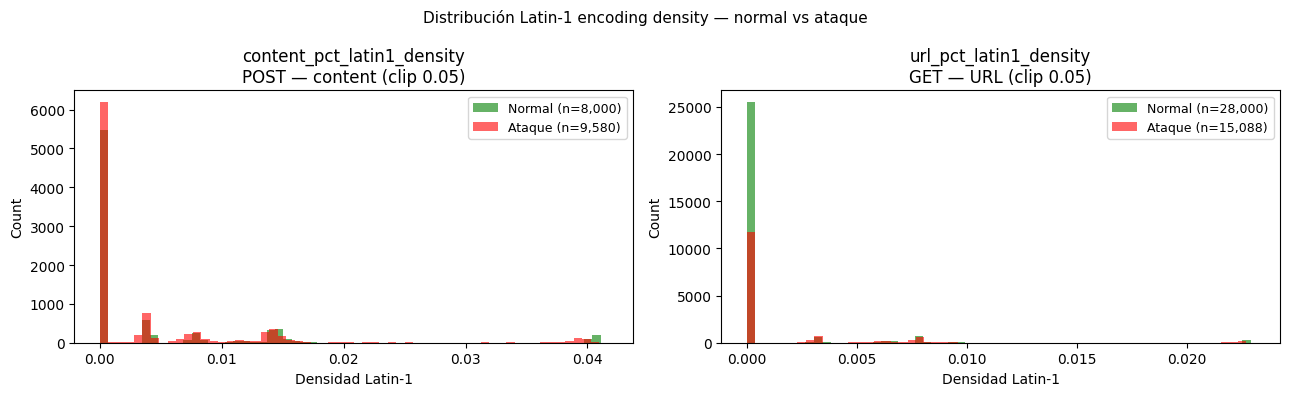

In [5]:
# Visualización
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for ax, feat, title, norm_pop, att_pop in [
    (axes[0], 'content_pct_latin1_density', 'POST — content', post_normal, post_attack),
    (axes[1], 'url_pct_latin1_density',     'GET — URL',      get_normal,  get_attack),
]:
    ax.hist(norm_pop[feat].clip(upper=0.05), bins=60, alpha=0.6, color='green',
            label=f'Normal (n={len(norm_pop):,})')
    ax.hist(att_pop[feat].clip(upper=0.05),  bins=60, alpha=0.6, color='red',
            label=f'Ataque (n={len(att_pop):,})')
    ax.set_title(f'{feat}\n{title} (clip 0.05)')
    ax.set_xlabel('Densidad Latin-1')
    ax.set_ylabel('Count')
    ax.legend(fontsize=9)

plt.suptitle('Distribución Latin-1 encoding density — normal vs ataque', fontsize=11)
plt.tight_layout()
plt.show()

## 3. Dataset v7 en memoria (25 features)

In [6]:
feature_cols_v7 = [
    'method_is_get', 'method_is_post', 'method_is_put',
    'url_length', 'url_param_count', 'url_pct_density',
    'url_path_depth', 'url_query_length', 'url_has_query',
    'url_has_pct27', 'url_has_pct3c', 'url_has_dashdash', 'url_has_script', 'url_has_select',
    # v7 — Latin-1 URL
    'url_pct_latin1_density',
    'content_length',
    'content_pct_density', 'content_param_count',
    'content_param_density',
    # v7 — Latin-1 content
    'content_pct_latin1_density',
    'content_has_pct27', 'content_has_pct3c', 'content_has_dashdash',
    'content_has_script', 'content_has_select',
    'label',
]

df_v7 = df_feat[feature_cols_v7].copy()
print(f'Dataset v7: {df_v7.shape}  |  {len(feature_cols_v7)-1} features + label')
print(f'Nuevas features: url_pct_latin1_density, content_pct_latin1_density')
print(f'NaN: {df_v7.isnull().sum().sum()}')

X = df_v7.drop(columns=['label']).values.astype('float32')
y = df_v7['label'].values
feature_names_v7 = df_v7.drop(columns=['label']).columns.tolist()

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=RANDOM_STATE
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=RANDOM_STATE
)
print(f'Train: {len(y_train)} | Val: {len(y_val)} | Test: {len(y_test)}')

continuous_features = ['url_length', 'url_query_length', 'content_length']
continuous_idx = [feature_names_v7.index(c) for c in continuous_features]
scaler = StandardScaler()
X_train[:, continuous_idx] = scaler.fit_transform(X_train[:, continuous_idx])
X_val[:, continuous_idx]   = scaler.transform(X_val[:, continuous_idx])
X_test[:, continuous_idx]  = scaler.transform(X_test[:, continuous_idx])

neg, pos = (y_train == 0).sum(), (y_train == 1).sum()
scale = neg / pos
print(f'scale_pos_weight: {scale:.3f}')

Dataset v7: (61065, 26)  |  25 features + label
Nuevas features: url_pct_latin1_density, content_pct_latin1_density
NaN: 0
Train: 42745 | Val: 9160 | Test: 9160
scale_pos_weight: 1.436


## 4. Entrenamiento v7 — 4 modelos

In [7]:
def find_best_threshold(y_true, y_proba, min_recall=MIN_RECALL_VAL):
    precs, recs, thrs = precision_recall_curve(y_true, y_proba)
    mask = recs[:-1] >= min_recall
    if not mask.any():
        return float(thrs[np.argmax(recs[:-1])])
    return float(thrs[np.where(mask, precs[:-1], 0).argmax()])

def evaluate(y_true, y_pred, y_proba, split_name):
    auc = roc_auc_score(y_true, y_proba)
    rc  = recall_score(y_true, y_pred)
    pr  = precision_score(y_true, y_pred)
    cm  = confusion_matrix(y_true, y_pred)
    fp  = cm[0, 1]
    print(f'  {split_name}')
    print(f'    ROC-AUC={auc:.4f}  Recall={rc:.4f} {"✅" if rc>=MIN_RECALL else "❌"}  '
          f'Precision={pr:.4f} {"✅" if pr>=MIN_PRECISION else "❌"}  FP={fp}')
    return {'roc_auc': auc, 'recall': rc, 'precision': pr, 'fp': fp}

def run_model_mlflow(name, model):
    algo_slug = name.lower().replace(' ', '')
    run_name  = f'model-a-{algo_slug}-features-v7'
    with mlflow.start_run(run_name=run_name):
        model.fit(X_train, y_train)
        val_proba  = model.predict_proba(X_val)[:, 1]
        threshold  = find_best_threshold(y_val, val_proba)
        val_pred   = (val_proba >= threshold).astype(int)
        test_proba = model.predict_proba(X_test)[:, 1]
        test_pred  = (test_proba >= threshold).astype(int)

        print(f'\n{"="*55}')
        print(f'{name}  |  threshold={threshold:.4f}')
        val_m  = evaluate(y_val,  val_pred,  val_proba,  'Val ')
        test_m = evaluate(y_test, test_pred, test_proba, 'Test')

        v6 = V6_RESULTS.get(name.replace(' ', ''), {})
        if v6:
            print(f'  Δ vs v6 → ROC-AUC:{test_m["roc_auc"]-v6["roc_auc"]:+.4f}  '
                  f'Recall:{test_m["recall"]-v6["recall"]:+.4f}  '
                  f'Precision:{test_m["precision"]-v6["precision"]:+.4f}  '
                  f'FP:{test_m["fp"]-v6["fp"]:+d}')

        mlflow.log_param('model', name)
        mlflow.log_param('features_version', 'v7')
        mlflow.log_param('n_features', X_train.shape[1])
        mlflow.log_param('threshold', round(threshold, 4))
        mlflow.log_param('min_recall_val', MIN_RECALL_VAL)
        mlflow.log_param('new_features', 'url_pct_latin1_density,content_pct_latin1_density')
        for k, v in test_m.items():
            mlflow.log_metric(k, round(v, 4))
        mlflow.log_metric('recall_val',    round(val_m['recall'],    4))
        mlflow.log_metric('precision_val', round(val_m['precision'], 4))
        run_id = mlflow.active_run().info.run_id[:8]
        print(f'  MLflow: {run_id}  {run_name}')
    return model, threshold, test_m, test_pred, test_proba

In [8]:
lr = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=RANDOM_STATE)
_, _, lr_m, _, _ = run_model_mlflow('LogisticRegression', lr)


LogisticRegression  |  threshold=0.2143
  Val 
    ROC-AUC=0.8157  Recall=0.9580 ✅  Precision=0.4718 ❌  FP=4032
  Test
    ROC-AUC=0.8198  Recall=0.9665 ✅  Precision=0.4751 ❌  FP=4015
  Δ vs v6 → ROC-AUC:-0.0004  Recall:-0.0032  Precision:+0.0012  FP:-32
  MLflow: 129edbe9  model-a-logisticregression-features-v7


In [9]:
rf = RandomForestClassifier(n_estimators=200, class_weight='balanced',
                             random_state=RANDOM_STATE, n_jobs=-1)
_, _, rf_m, _, _ = run_model_mlflow('RandomForest', rf)


RandomForest  |  threshold=0.0962
  Val 
    ROC-AUC=0.9598  Recall=0.9564 ✅  Precision=0.7439 ❌  FP=1238
  Test
    ROC-AUC=0.9607  Recall=0.9503 ✅  Precision=0.7551 ❌  FP=1159
  Δ vs v6 → ROC-AUC:+0.0001  Recall:+0.0019  Precision:-0.0232  FP:+143
  MLflow: 1500b824  model-a-randomforest-features-v7


In [10]:
xgb = XGBClassifier(n_estimators=200, scale_pos_weight=scale,
                     eval_metric='logloss', random_state=RANDOM_STATE, n_jobs=-1, verbosity=0)
_, _, xgb_m, _, _ = run_model_mlflow('XGBoost', xgb)


XGBoost  |  threshold=0.1794
  Val 
    ROC-AUC=0.9613  Recall=0.9561 ✅  Precision=0.7586 ❌  FP=1144
  Test
    ROC-AUC=0.9652  Recall=0.9559 ✅  Precision=0.7731 ❌  FP=1055
  Δ vs v6 → ROC-AUC:+0.0018  Recall:-0.0015  Precision:+0.0012  FP:-9
  MLflow: 341a9223  model-a-xgboost-features-v7


In [11]:
lgbm = LGBMClassifier(n_estimators=200, scale_pos_weight=scale,
                       random_state=RANDOM_STATE, n_jobs=-1, verbose=-1)
lgbm_model, lgbm_thr, lgbm_m, lgbm_pred, lgbm_proba = run_model_mlflow('LightGBM', lgbm)


LightGBM  |  threshold=0.2573
  Val 
    ROC-AUC=0.9656  Recall=0.9551 ✅  Precision=0.7882 ❌  FP=965
  Test
    ROC-AUC=0.9677  Recall=0.9529 ✅  Precision=0.7929 ❌  FP=936
  Δ vs v6 → ROC-AUC:+0.0016  Recall:-0.0019  Precision:+0.0001  FP:-2
  MLflow: c324691d  model-a-lightgbm-features-v7


In [12]:
# Tabla resumen
results = {'LogisticRegression': lr_m, 'RandomForest': rf_m, 'XGBoost': xgb_m, 'LightGBM': lgbm_m}
print('\nResumen v7 vs v6')
print('=' * 90)
print(f'{"Modelo":<22} {"ROC-AUC":>8} {"Δv6":>7} {"Recall":>8} {"Δv6":>7} {"Precision":>10} {"Δv6":>7} {"FP":>6} {"Δv6":>7}')
print('-' * 90)
for name, m in results.items():
    v6 = V6_RESULTS.get(name, {})
    if v6:
        print(f'{name:<22} {m["roc_auc"]:>8.4f} {m["roc_auc"]-v6["roc_auc"]:>+7.4f} '
              f'{m["recall"]:>8.4f} {m["recall"]-v6["recall"]:>+7.4f} '
              f'{m["precision"]:>10.4f} {m["precision"]-v6["precision"]:>+7.4f} '
              f'{m["fp"]:>6d} {m["fp"]-v6["fp"]:>+7d}')
print('=' * 90)
print(f'Criterios: Recall ≥ {MIN_RECALL}  |  Precision ≥ {MIN_PRECISION}')


Resumen v7 vs v6
Modelo                  ROC-AUC     Δv6   Recall     Δv6  Precision     Δv6     FP     Δv6
------------------------------------------------------------------------------------------
LogisticRegression       0.8198 -0.0004   0.9665 -0.0032     0.4751 +0.0012   4015     -32
RandomForest             0.9607 +0.0001   0.9503 +0.0019     0.7551 -0.0232   1159    +143
XGBoost                  0.9652 +0.0018   0.9559 -0.0015     0.7731 +0.0012   1055      -9
LightGBM                 0.9677 +0.0016   0.9529 -0.0019     0.7929 +0.0001    936      -2
Criterios: Recall ≥ 0.95  |  Precision ≥ 0.85


## 5. Feature importance — LightGBM v7

In [13]:
fi_df = pd.DataFrame({
    'feature':    feature_names_v7,
    'importance': lgbm_model.feature_importances_
}).sort_values('importance', ascending=False)

print('Feature importance — LightGBM v7')
print(fi_df.to_string(index=False))

# Posición de las nuevas features
for feat in ['content_pct_latin1_density', 'url_pct_latin1_density']:
    row = fi_df[fi_df['feature'] == feat]
    if not row.empty:
        rank = fi_df.index.get_loc(row.index[0]) + 1
        print(f'\n{feat}: rank {rank}  importance {row["importance"].values[0]}')

Feature importance — LightGBM v7
                   feature  importance
                url_length        1321
            content_length         701
       content_pct_density         667
          url_query_length         637
           url_pct_density         600
content_pct_latin1_density         540
    url_pct_latin1_density         527
     content_param_density         499
            url_path_depth         222
           url_param_count          62
             method_is_put          55
         content_has_pct27          47
             url_has_pct27          36
            url_has_script          31
            url_has_select          20
             method_is_get          17
            method_is_post          14
       content_param_count           3
      content_has_dashdash           1
          url_has_dashdash           0
             url_has_pct3c           0
             url_has_query           0
         content_has_pct3c           0
        content_has_script     

## 6. Conclusiones v7

In [14]:
v6_lgbm = V6_RESULTS['LightGBM']
print('LightGBM v7 vs v6:')
print(f'  Recall    : {lgbm_m["recall"]:.4f}  {"✅" if lgbm_m["recall"] >= MIN_RECALL else "❌"}  (Δ {lgbm_m["recall"]-v6_lgbm["recall"]:+.4f})')
print(f'  Precision : {lgbm_m["precision"]:.4f}  {"✅" if lgbm_m["precision"] >= MIN_PRECISION else "❌"}  (Δ {lgbm_m["precision"]-v6_lgbm["precision"]:+.4f})')
print(f'  FP        : {lgbm_m["fp"]}  (Δ {lgbm_m["fp"]-v6_lgbm["fp"]:+d})')
print(f'  ROC-AUC   : {lgbm_m["roc_auc"]:.4f}  (Δ {lgbm_m["roc_auc"]-v6_lgbm["roc_auc"]:+.4f})')
print(f'  Gap Precision restante: {MIN_PRECISION - lgbm_m["precision"]:.4f}')
print()

delta_pr = lgbm_m['precision'] - v6_lgbm['precision']
delta_fp = lgbm_m['fp'] - v6_lgbm['fp']

if delta_pr > 0.01 and lgbm_m['recall'] >= MIN_RECALL:
    print('→ Señal confirmada: Precision mejoró significativamente con Recall mantenido')
    print('→ Decisión: incorporar al preprocessing oficial (preprocess_csic_v4.py)')
    print('→ preprocess_csic_v4.py generará features_v4.parquet con 25 features')
elif delta_pr > 0 and lgbm_m['recall'] >= MIN_RECALL:
    print('→ Mejora marginal — evaluar si es consistente entre modelos antes de incorporar')
elif delta_pr <= 0:
    print('→ Sin mejora en Precision — hipótesis Latin-1 no confirmada por el modelo')
    print('→ Revisar: ¿el modelo ya capturaba esta señal de otra forma?')

if lgbm_m['precision'] >= MIN_PRECISION:
    print()
    print('🎯 MVP TARGET ALCANZADO — Precision ≥ 0.85 con Recall ≥ 0.95')

LightGBM v7 vs v6:
  Recall    : 0.9529  ✅  (Δ -0.0019)
  Precision : 0.7929  ❌  (Δ +0.0001)
  FP        : 936  (Δ -2)
  ROC-AUC   : 0.9677  (Δ +0.0016)
  Gap Precision restante: 0.0571

→ Mejora marginal — evaluar si es consistente entre modelos antes de incorporar
